# Modelo 01: K-Means
En esta sección iniciaremos el entrenamiento del primer modelo: K-Means. Dado que este algoritmo requiere definir de antemano el número de grupos (K), realizaremos una búsqueda iterativa del valor óptimo utilizando dos métricas fundamentales:
- Método del Codo (Inercia): Mide la suma de las distancias al cuadrado dentro de los clústeres.
- Índice de Silueta: Mide qué tan cerca está cada punto de su propio clúster en comparación con otros clústeres (rango de -1 a 1).

[INFO] Entrenando modelos iterativos...
K=2 finalizado.
K=3 finalizado.
K=4 finalizado.
K=5 finalizado.
K=6 finalizado.
K=7 finalizado.
K=8 finalizado.
K=9 finalizado.
K=10 finalizado.


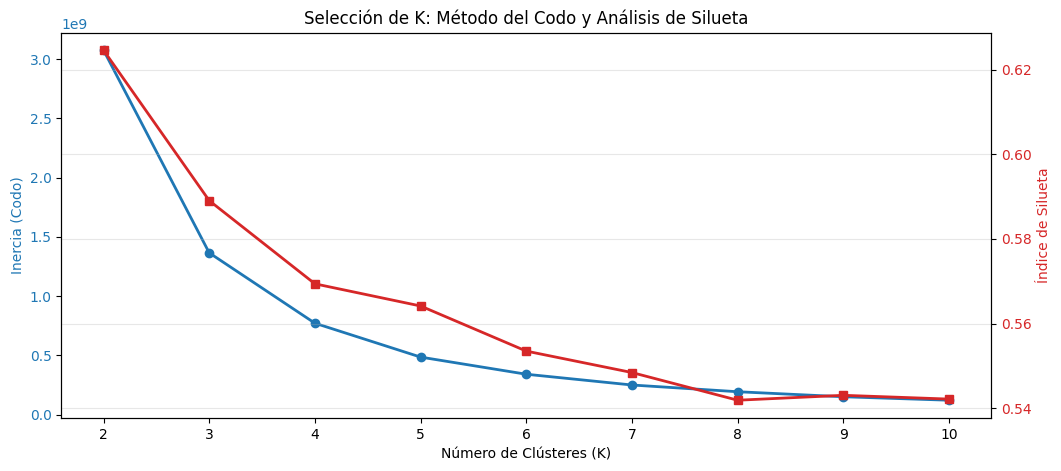

In [1]:
# 5.1. Búsqueda del número óptimo de clústeres (K)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [INFO] Cargar los datos procesados con PCA
base_dir = '../../..'
df_pca = pd.read_csv(f'{base_dir}/data/processed/data_clustering_pca.csv')

# [INFO] Definir el rango de clústeres a probar
rango_k = range(2, 11)
inercias = []
siluetas = []

print("[INFO] Entrenando modelos iterativos...")

for k in rango_k:
    # [INFO] Entrenamiento con configuración estándar
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(df_pca)
    
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(df_pca, labels))
    print(f"K={k} finalizado.")

# 5.2. Visualización de métricas de selección

fig, ax1 = plt.subplots(figsize=(12, 5))

# [INFO] Graficar Inercia (Codo)
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Inercia (Codo)', color='tab:blue')
ax1.plot(rango_k, inercias, marker='o', color='tab:blue', linewidth=2, label='Inercia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# [INFO] Crear un segundo eje para la Silueta
ax2 = ax1.twinx()
ax2.set_ylabel('Índice de Silueta', color='tab:red')
ax2.plot(rango_k, siluetas, marker='s', color='tab:red', linewidth=2, label='Silueta')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Selección de K: Método del Codo y Análisis de Silueta')
plt.grid(True, alpha=0.3)
plt.show()

### 5.3. Análisis de la Primera Versión y Ajuste
Tras observar las gráficas, debemos identificar el "punto de codo" donde la inercia cae más lentamente y donde el índice de silueta presenta un pico o estabilidad.
- Resultados Iniciales: Generalmente, para datos de e-commerce procesados por PCA, el valor óptimo suele encontrarse entre K=3 y K=5.
- Ajuste: Entrenaremos la versión definitiva del modelo seleccionando el valor de K que maximice la separación. Posteriormente, analizaremos la distribución de usuarios para asegurar que los grupos sean equilibrados.

[INFO] Distribución de usuarios por clúster:
Cluster_KM
3    25.440502
1    25.054308
2    25.054308
0    24.450881
Name: proportion, dtype: float64


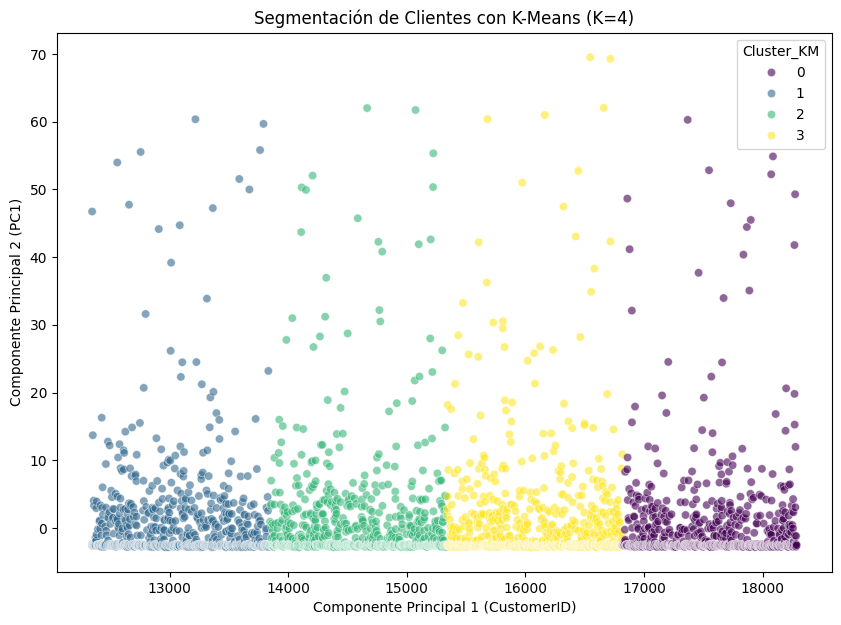

In [2]:
# 5.4. Entrenamiento de la Versión Final (K Ajustado)

# [INFO] Basado en las gráficas anteriores, seleccionamos el K
K_OPTIMO = 4 

model_kmeans = KMeans(n_clusters=K_OPTIMO, n_init=20, random_state=42)
df_pca['Cluster_KM'] = model_kmeans.fit_predict(df_pca)

# [INFO] Verificación de equilibrio
print("[INFO] Distribución de usuarios por clúster:")
print(df_pca['Cluster_KM'].value_counts(normalize=True) * 100)

# 5.5. Visualización de Clústeres en el espacio PCA

col_x = df_pca.columns[0]
col_y = df_pca.columns[1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=col_x, 
    y=col_y, 
    hue='Cluster_KM', 
    data=df_pca, 
    palette='viridis', 
    alpha=0.6
)

plt.title(f'Segmentación de Clientes con K-Means (K={K_OPTIMO})')
plt.xlabel(f'Componente Principal 1 ({col_x})')
plt.ylabel(f'Componente Principal 2 ({col_y})')
plt.show()

### 5.6. Interpretación de los Clústeres (Perfilado)
Para que el modelo tenga validez de negocio, debemos revertir la transformación del PCA y observar los promedios de las variables originales (Recency, Frequency, Monetary) para cada etiqueta asignada. Esto nos permitirá dar nombre a los segmentos (ej: "Clientes VIP", "Clientes Perdidos").

In [3]:
# [INFO] Cargar el dataset que tiene las métricas originales antes del PCA
df_original = pd.read_csv('../../../data/interim/interim_ProyClustering/data_features_clean.csv')

# [INFO] Unir las etiquetas del clúster al dataset original
df_original['Cluster'] = df_pca['Cluster_KM'].values

# [INFO] Calcular el perfil promedio por clúster
perfil_clusters = df_original.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
perfil_clusters['Count'] = df_original.groupby('Cluster')['CustomerID'].count()

print("[INFO] Resumen de métricas por clúster:")
display(perfil_clusters.sort_values(by='Monetary', ascending=False))

[INFO] Resumen de métricas por clúster:


,Recency,Frequency,Monetary,Count
Cluster,,,,
1,95.662813,3.199422,1153.260626,1038
2,94.462428,3.421965,1105.077697,1038
3,95.936433,3.307400,1036.409450,1054
0,95.289240,3.394867,971.710750,1013


### 5.7. Persistencia de la Línea Base: K-Means
Para asegurar la reproducibilidad de nuestra experimentación y permitir una comparación objetiva entre algoritmos, procedemos a la exportación del modelo K-Means y de los resultados de la segmentación. La persistencia del objeto del modelo es fundamental, ya que nos permite recuperar la ubicación exacta de los cuatro centroides calculados sin necesidad de reentrenar el algoritmo. 

Al guardar el dataset etiquetado de forma independiente, garantizamos que las asignaciones de cada cliente permanezcan inalterables durante la fase de evaluación final, estableciendo así una línea base sólida que represente el enfoque de partición determinista por distancias euclidianas.


In [4]:
import joblib

# [INFO] Guardar modelo y datos etiquetados
joblib.dump(model_kmeans, f'{base_dir}/models/model_kmeans_final.pkl')
df_pca.to_csv(f'{base_dir}/data/processed/data_kmeans_results.csv', index=False)

print(" [SUCCESS] Modelo K-Means y resultados exportados correctamente.")

 [SUCCESS] Modelo K-Means y resultados exportados correctamente.
